In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pk_df = pd.read_csv("PK Studies.csv")
pk_df.columns = pk_df.columns.str.strip()

interactions = []

for index, row in pk_df.iterrows():
    main_drug = row.get('Generic Name')
    drug_class = row.get('Class')

    for i in range(1, 23):
        drug_col = f'Drug {i}'
        type_col = 'Type' if i == 1 else f'Type.{i-1}'
        aucr_col = 'AUCR' if i == 1 else f'AUCR.{i-1}'
        
        if drug_col in pk_df.columns and pd.notna(row[drug_col]):
            interacting_drug = row[drug_col]
            interaction_type = row.get(type_col, 'Unknown')
            aucr_value = row.get(aucr_col, np.nan)
            
            try:
                aucr_value = float(aucr_value)
            except:
                aucr_value = np.nan
                
            if pd.notna(aucr_value) and aucr_value > 0:
                interactions.append({
                    'Main_Drug': main_drug,
                    'Interacting_Drug': interacting_drug,
                    'Main_Class': drug_class,
                    'Interaction_Type': interaction_type,
                    'AUCR': aucr_value
                })

clean_pk_df = pd.DataFrame(interactions)

outcomes_df = pd.read_csv("Outcome Studies.csv")
outcomes_df.columns = outcomes_df.columns.str.strip()

merged_df = pd.merge(clean_pk_df, outcomes_df[['Generic Name', 'Outcome(s)']], 
                     left_on='Main_Drug', right_on='Generic Name', how='inner')

merged_df = merged_df.drop('Generic Name', axis=1).dropna(subset=['AUCR', 'Outcome(s)'])

print(f"Data Engineering Complete! Ready for analysis. Shape: {merged_df.shape}")
display(merged_df.head())

Data Engineering Complete! Ready for analysis. Shape: (66, 6)


,Main_Drug,Interacting_Drug,Main_Class,Interaction_Type,AUCR,Outcome(s)
75,Axitinib,Rifampin (M),TKI,DDI,0.21,No difference in PFS or ORR
76,Axitinib,Ketoconazole,TKI,DDI,2.06,No difference in PFS or ORR
77,Axitinib,Rabeprazole,TKI,DDI,0.85,No difference in PFS or ORR
150,Dasatinib,Rifampin (M),TKI (BCR-ABL),DDI,0.18,Combination treatment with PPIs or H2RAs did n...
151,Dasatinib,Ketoconazole,TKI (BCR-ABL),DDI,4.84,Combination treatment with PPIs or H2RAs did n...


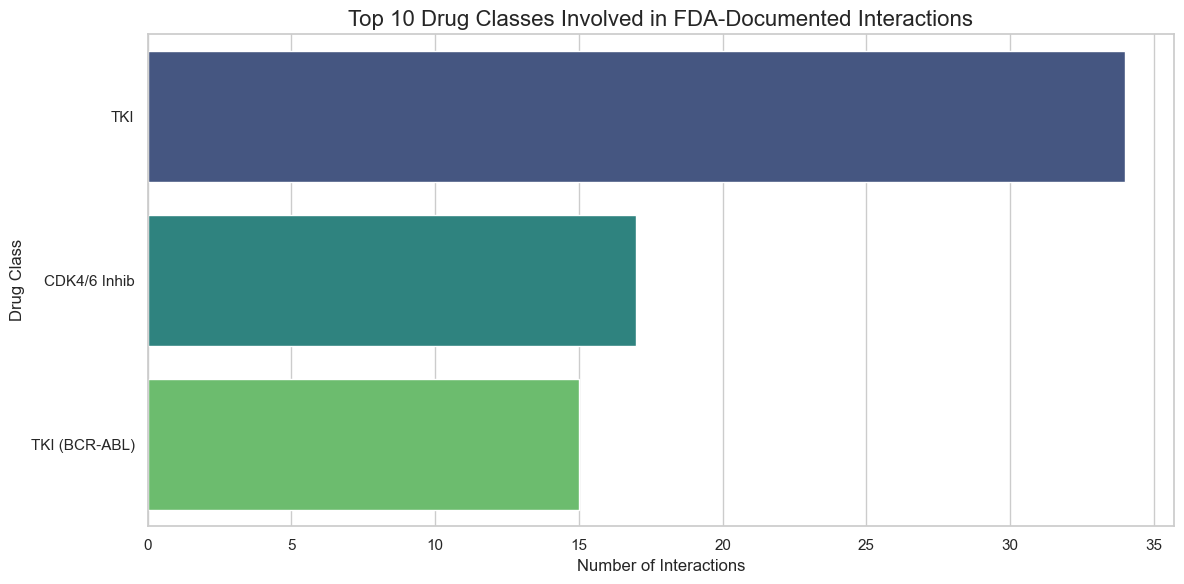

In [ ]:
plt.figure(figsize=(12, 6))

top_classes = merged_df['Main_Class'].value_counts().head(10)

sns.barplot(x=top_classes.values, y=top_classes.index, palette="viridis")

plt.title('Top 10 Drug Classes Involved in FDA-Documented Interactions', fontsize=16)
plt.xlabel('Number of Interactions', fontsize=12)
plt.ylabel('Drug Class', fontsize=12)
plt.tight_layout()
plt.show()

Plotting 9 severe interaction pathways...


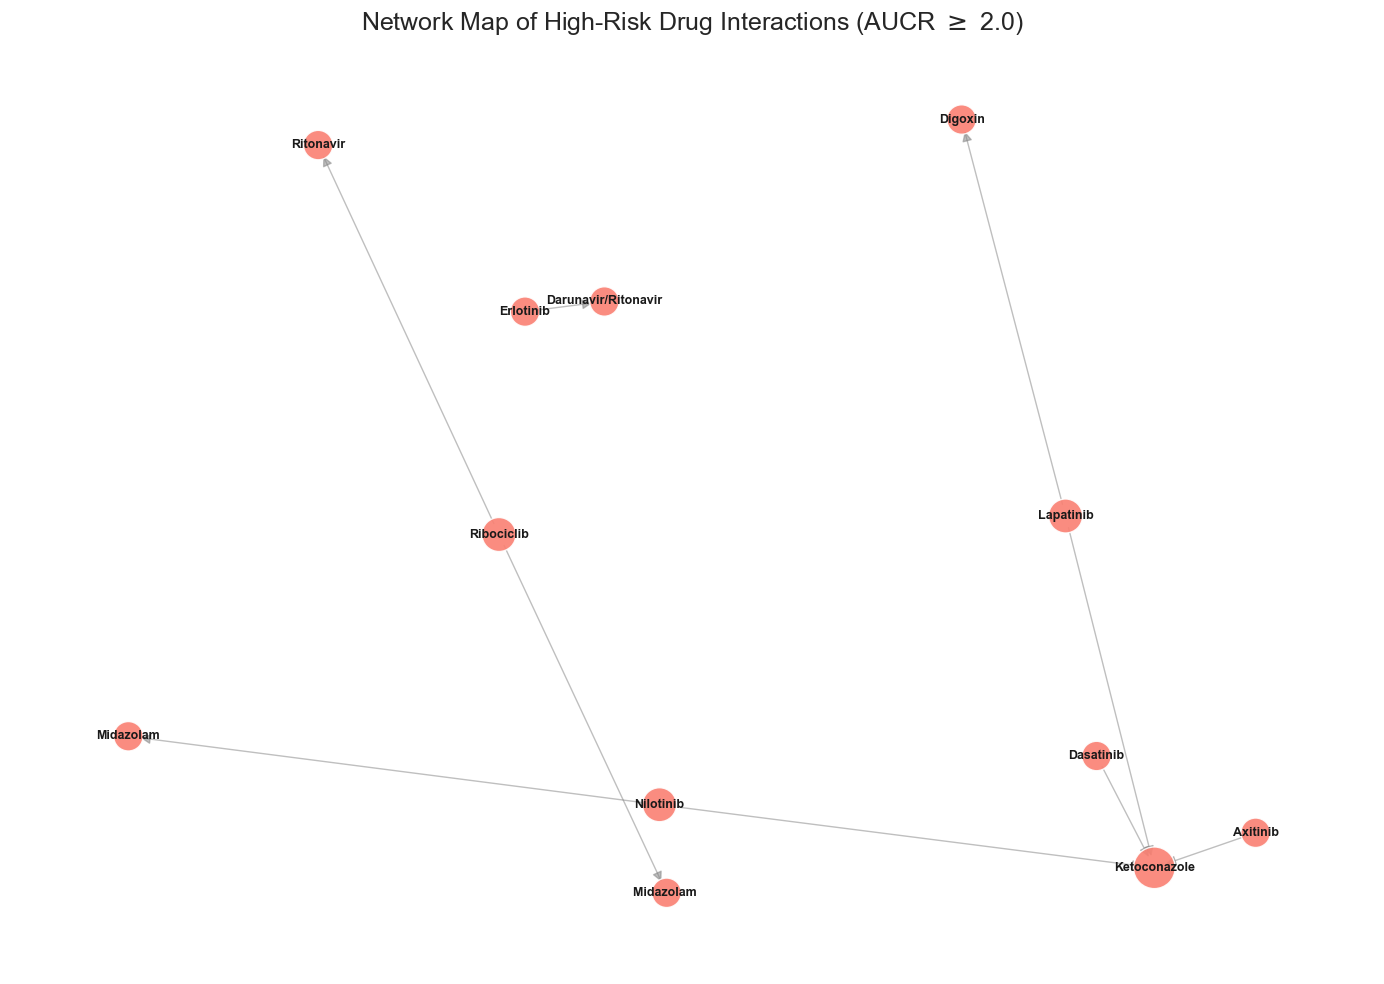

In [ ]:
severe_interactions = merged_df[merged_df['AUCR'] >= 2.0]

print(f"Plotting {len(severe_interactions)} severe interaction pathways...")

G = nx.DiGraph()

for index, row in severe_interactions.iterrows():
    G.add_edge(row['Main_Drug'], row['Interacting_Drug'], weight=row['AUCR'])
    
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, k=0.4, iterations=50)

d = dict(G.degree)
node_sizes = [v * 150 + 300 for v in d.values()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='salmon', alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=15, width=1.0, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title("Network Map of High-Risk Drug Interactions (AUCR $\geq$ 2.0)", fontsize=18)
plt.axis('off')
plt.tight_layout()
plt.show()

Training Random Forest Regressor to predict AUCR...

Training on 52 samples. Testing on 14 unseen samples.
Model Mean Squared Error (MSE): 0.5726


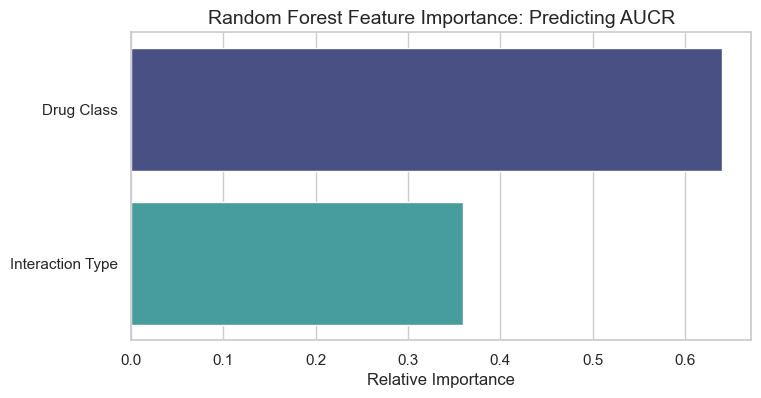

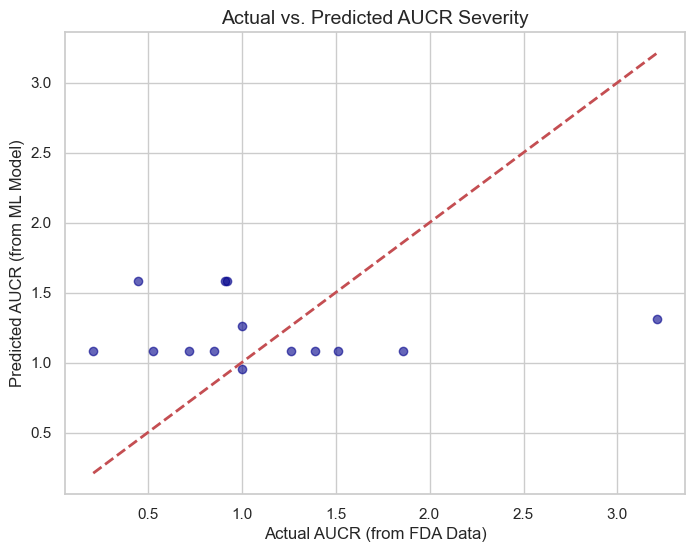

In [ ]:
print("Training Random Forest Regressor to predict AUCR...\n")

ml_df = merged_df.copy()

le_class = LabelEncoder()
le_type = LabelEncoder()

ml_df['Class_Encoded'] = le_class.fit_transform(ml_df['Main_Class'])
ml_df['Type_Encoded'] = le_type.fit_transform(ml_df['Interaction_Type'])

# Define Features (X) and Target (y)
X = ml_df[['Class_Encoded', 'Type_Encoded']]
y = ml_df['AUCR']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} samples. Testing on {len(X_test)} unseen samples.")

# 3. Initialize and Train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make Predictions on the Test Set
predictions = rf_model.predict(X_test)

# 5. Evaluate the Model
mse = mean_squared_error(y_test, predictions)
print(f"Model Mean Squared Error (MSE): {mse:.4f}")

# 6. Plot Feature Importance
importances = rf_model.feature_importances_
features = ['Drug Class', 'Interaction Type']

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette="mako")
plt.title('Random Forest Feature Importance: Predicting AUCR', fontsize=14)
plt.xlabel('Relative Importance')
plt.show()

# 7. Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line of perfect prediction
plt.title('Actual vs. Predicted AUCR Severity', fontsize=14)
plt.xlabel('Actual AUCR (from FDA Data)')
plt.ylabel('Predicted AUCR (from ML Model)')
plt.show()